# Iowa Corn Hedging: Master Python Framework

The framework answers one decision question:

> Under the stated historical data, calibration, cost, basis, and liquidity
> assumptions, which December corn futures hedge provides the strongest
> protection in the lower 5% of farm-profit outcomes without materially
> sacrificing expected profit or creating excessive over-hedging?

The framework preserves the lessons' timing discipline:

1. A March hedge can use only the trend yield and the March futures price.
2. A July adjustment can use July PDSI, the July yield forecast, and the July
   futures price, but not the final yield residual.
3. Harvest profit uses realized yield, harvest futures, and local basis.
4. Every strategy faces the same 10,000 scenarios (common random numbers).

Project folder: /Users/wanzhuzheng/Desktop/Iowa_Corn_Hedging_Project/data
Scenarios: 10,000

Yield and price calibration diagnostics:


,section,model,predictors,eligible_for_selection,n_observations,n_estimated_parameters,r_squared,adjusted_r_squared,in_sample_rmse,residual_standard_deviation,loocv_rmse,selected
0,yield_model,trend_only,trend_index,True,30,2,0.7555,0.7467,11.3788,11.7781,11.9343,False
1,yield_model,trend_plus_precip,trend_index + may_july_precip_inches,True,30,3,0.7649,0.7475,11.1564,11.7599,12.6279,False
2,yield_model,trend_plus_temperature,trend_index + may_july_avg_temp_f,True,30,3,0.7857,0.7699,10.6517,11.2279,12.6232,False
3,yield_model,trend_plus_pdsi,trend_index + july_pdsi,True,30,3,0.7946,0.7793,10.4300,10.9942,11.9201,True
4,yield_model,trend_plus_precip_temperature,trend_index + may_july_precip_inches + may_jul...,False,30,4,0.7875,0.7629,10.6083,11.3952,12.9858,False
5,yield_model,trend_plus_precip_pdsi,trend_index + may_july_precip_inches + july_pdsi,False,30,4,0.8100,0.7881,10.0292,10.7731,11.7555,False
6,yield_model,trend_plus_temperature_pdsi,trend_index + may_july_avg_temp_f + july_pdsi,False,30,4,0.8058,0.7834,10.1403,10.8924,12.4869,False
7,yield_model,trend_plus_all_weather,trend_index + may_july_precip_inches + may_jul...,False,30,5,0.8219,0.7934,9.7111,10.6380,12.4420,False
8,price_model,july_futures_change,july_weather_yield_signal,True,30,2,0.0215,-0.0134,0.6057,0.6269,0.6893,True
9,price_model,harvest_futures_change,final_yield_surprise_vs_trend,True,30,2,0.1443,0.1138,0.7206,0.7459,0.8044,True



Main strategy comparison:


,strategy,Expected Profit ($/acre),Profit Std Dev ($/acre),Probability Profit < 0,P5 Profit ($/acre),CVaR 5% Profit ($/acre),Probability Overhedged,Probability Margin Call Proxy,Eligible,Preferred
0,Fixed 0%,-1.5945,153.7293,0.5543,-308.6272,-338.7472,0.0000,0.0000,True,False
1,Fixed 25%,5.4811,113.6742,0.5145,-223.6045,-240.0046,0.0000,0.1435,True,False
2,Fixed 50%,11.9133,80.0589,0.4311,-144.9767,-154.8016,0.0000,0.3716,True,False
3,Fixed 75%,18.9889,52.8491,0.3370,-67.6508,-94.9466,0.0000,0.4751,True,True
4,Fixed 100%,25.4211,52.2507,0.2401,-71.8223,-118.1374,0.4538,0.5330,False,False
5,Updated 50%,12.0031,79.9664,0.4302,-144.0852,-155.0416,0.0000,0.3710,True,False
6,Weather-signal 25/50/75%,13.1318,87.4384,0.4205,-132.0781,-201.4749,0.0000,0.3463,True,False



Preferred strategy: Fixed 75%
July price beta = 0 preferred strategy: Fixed 75%
Recommendation unchanged: True
Outputs saved to: /Users/wanzhuzheng/Desktop/Iowa_Corn_Hedging_Project/data/master_outputs


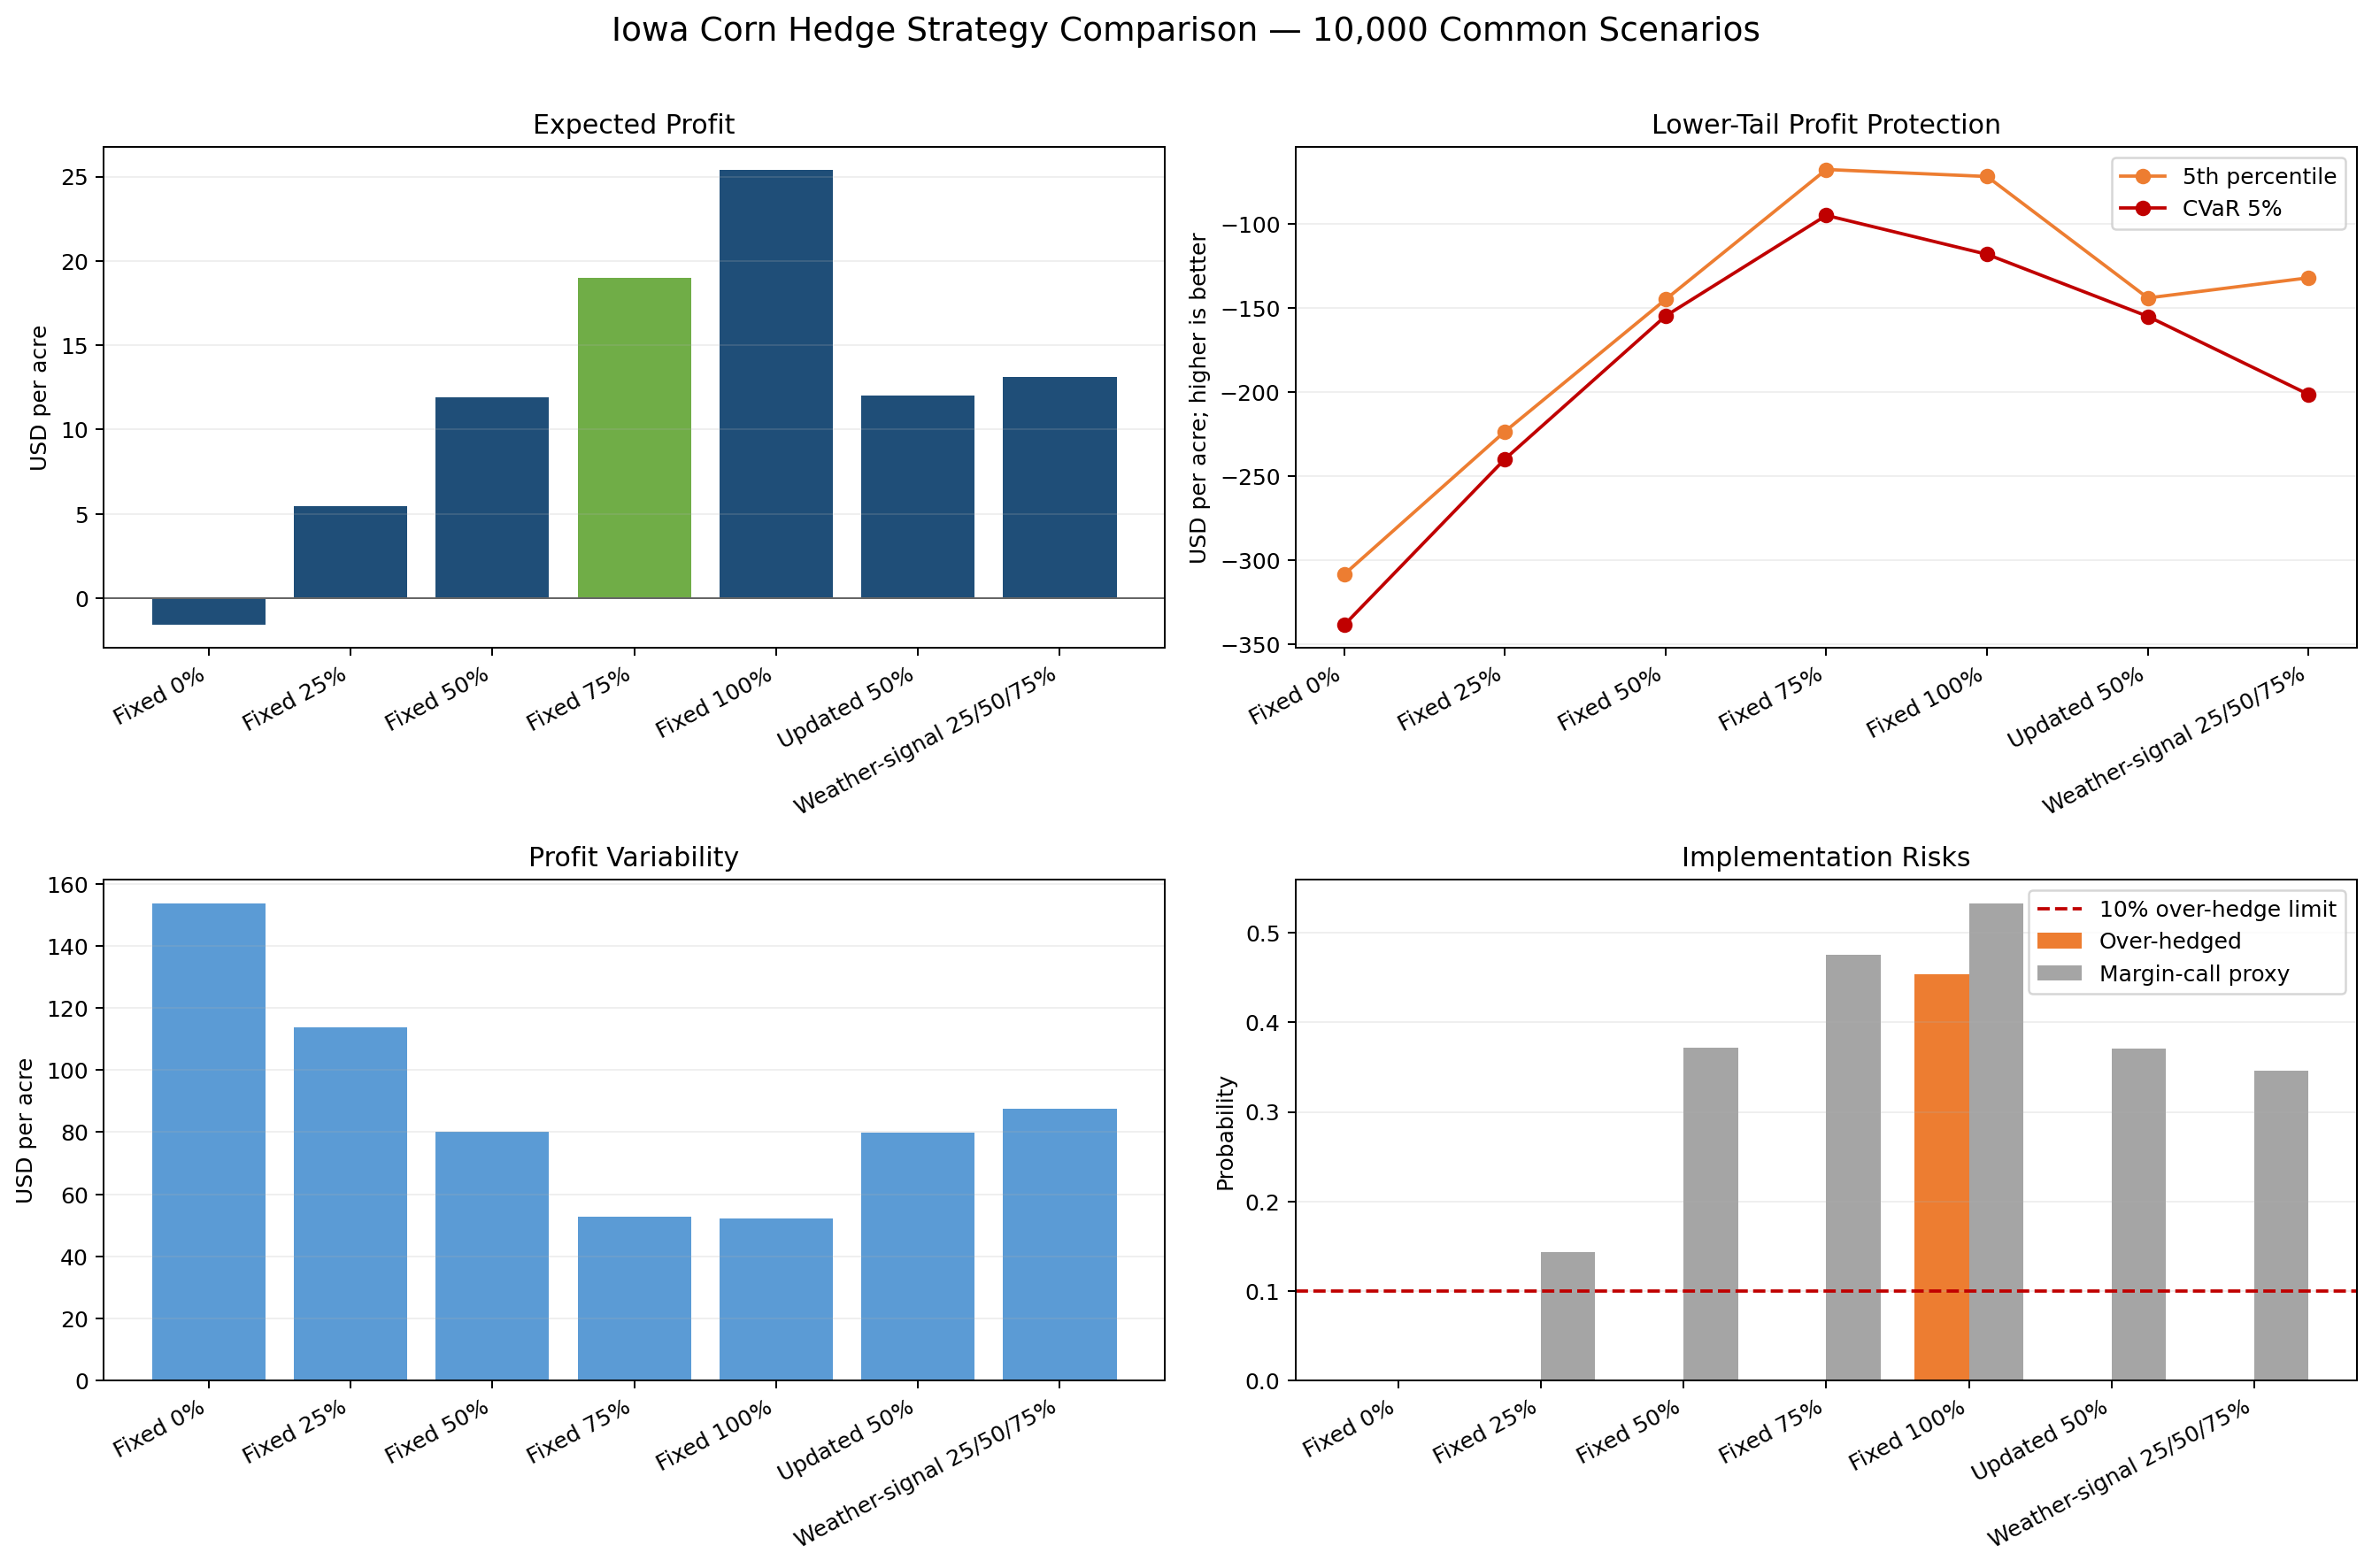

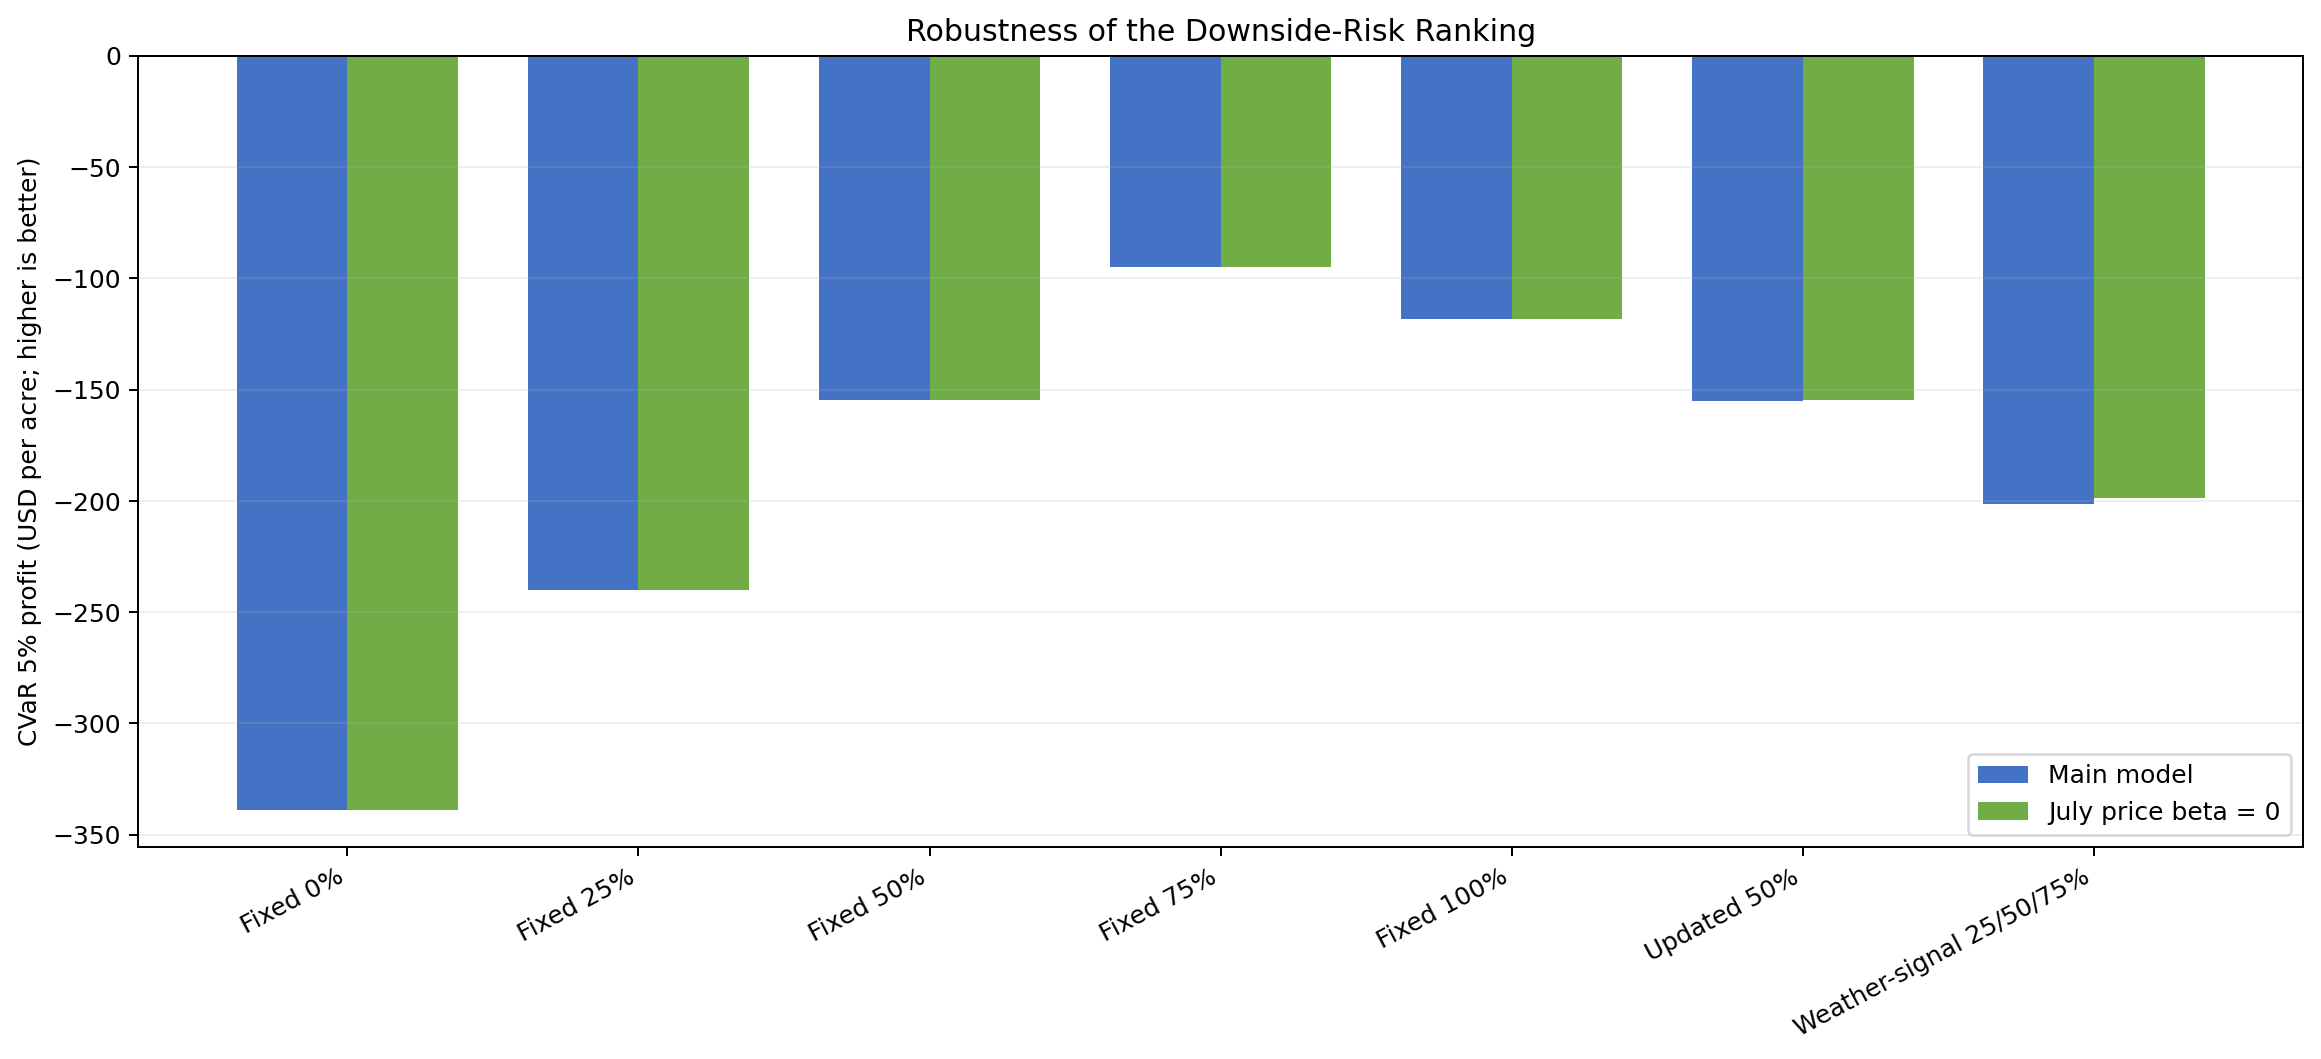

In [5]:
from pathlib import Path
import importlib.util
import sys

from IPython.display import Image, display


def locate_project_root():
    """Find the folder containing both the master source and processed data."""
    starting_points = [Path.cwd()]
    starting_points.extend(Path(entry) for entry in sys.path if entry)

    checked = set()
    for starting_point in starting_points:
        try:
            starting_point = starting_point.resolve()
        except (OSError, RuntimeError):
            continue
        for candidate in (starting_point, *starting_point.parents):
            if candidate in checked:
                continue
            checked.add(candidate)
            source_exists = (candidate / "Iowa_Corn_Hedging_Master_Framework.py").is_file()
            data_exists = (
                candidate
                / "processed"
                / "iowa_calibration_panel_1996_2025.csv"
            ).is_file()
            if source_exists and data_exists:
                return candidate

    raise FileNotFoundError(
        "Could not find the project folder. Open this notebook from the same "
        "folder as Iowa_Corn_Hedging_Master_Framework.py and processed/."
    )


PROJECT_ROOT = locate_project_root()
MASTER_SOURCE = PROJECT_ROOT / "Iowa_Corn_Hedging_Master_Framework.py"

# Load the master source directly, so the notebook always runs the current file.
module_name = "iowa_corn_hedging_master_runtime"
module_spec = importlib.util.spec_from_file_location(module_name, MASTER_SOURCE)
if module_spec is None or module_spec.loader is None:
    raise ImportError(f"Could not load the master framework from {MASTER_SOURCE}")

master = importlib.util.module_from_spec(module_spec)
sys.modules[module_name] = master
module_spec.loader.exec_module(master)

CONFIG = master.ModelConfig()
RESULTS = master.run_master_framework(PROJECT_ROOT, CONFIG)
OUTPUT_PATHS = master.write_outputs(
    RESULTS,
    PROJECT_ROOT / "master_outputs",
)

summary_columns = [
    "strategy",
    "Expected Profit ($/acre)",
    "Profit Std Dev ($/acre)",
    "Probability Profit < 0",
    "P5 Profit ($/acre)",
    "CVaR 5% Profit ($/acre)",
    "Probability Overhedged",
    "Probability Margin Call Proxy",
    "Eligible",
    "Preferred",
]

print(f"Project folder: {PROJECT_ROOT}")
print(f"Scenarios: {len(RESULTS.scenarios):,}")
print("\nYield and price calibration diagnostics:")
display(RESULTS.calibration.diagnostics.round(4))

print("\nMain strategy comparison:")
display(RESULTS.main_summary[summary_columns].round(4))

print(f"\nPreferred strategy: {RESULTS.main_decision.preferred_strategy}")
print(
    "July price beta = 0 preferred strategy: "
    f"{RESULTS.robustness_decision.preferred_strategy}"
)
print(
    "Recommendation unchanged: "
    f"{RESULTS.diagnostics['recommendation_stable_when_july_beta_is_zero']}"
)
print(f"Outputs saved to: {PROJECT_ROOT / 'master_outputs'}")

display(Image(filename=str(OUTPUT_PATHS["strategy_figure"])))
display(Image(filename=str(OUTPUT_PATHS["robustness_figure"])))


## 0. Model governance and pre-specified decision framework

All economic and implementation assumptions are centralized below. These
values match the eleven lessons and the final Excel workbook. They are model
assumptions—not broker quotes, guarantees, or trading advice.

The preferred strategy is selected only after applying two safeguards:

- **Expected-profit safeguard:** mean profit may not be more than
  `5% × |unhedged mean profit|` below the unhedged mean.
- **Over-hedging safeguard:** the probability that hedged bushels exceed
  actual production may not exceed 10%.

Among eligible strategies, the highest lower-tail 5% profit CVaR wins. Here,
CVaR is the average profit at or below the 5th percentile, so a larger (less
negative) value is better. If CVaR ties, higher expected profit breaks the tie.

## 1. Historical data and the long-run yield trend

The calibration panel covers 1996–2025. The first model is:

\[
TrendYield_t = \beta_0 + \beta_1(Year_t - 1996).
\]

Centering the year makes the intercept interpretable as the 1996 trend yield.
Residuals are always defined as `actual − fitted`.

## 2. July PDSI yield model and model-selection discipline

The selected July model is:

\[
Yield_t = \beta_0 + \beta_1 TrendIndex_t + \beta_2 JulyPDSI_t + \epsilon_t.
\]

PDSI is interpreted as a historical association, not a causal estimate. A
higher PDSI generally means wetter conditions. To avoid selecting a model
merely because it fits the 30 observations well, the framework compares
leave-one-out cross-validation RMSE. The eligible set is trend-only plus each
trend-plus-one-weather-variable model; larger weather combinations are kept as
robustness diagnostics rather than allowed to win the primary selection.

## 3. Historical residual bootstrap for yield

July PDSI and the selected yield-model residual are sampled independently from
their historical empirical distributions. The July forecast uses PDSI; final
yield adds a residual only after the July decision:

\[
\widehat{Y}_{July,i}=\beta_0+\beta_1(30)+\beta_2PDSI_i
\]

\[
Y_i=\max(0,\widehat{Y}_{July,i}+e^Y_i).
\]

Independent weather and yield-residual draws are an explicit modeling choice.
They allow new combinations of historically observed shocks, but they do not
claim those components are structurally independent in reality.

## 4. Futures-price calibration

Price changes are measured from the March preseason futures price, not from
one observation date to the next:

\[
\Delta F_{July}=\alpha_J+\gamma_J(JulyYieldForecast-TrendYield)+e^J
\]

\[
\Delta F_{Harvest}=\alpha_H+\gamma_H(FinalYield-TrendYield)+e^H.
\]

July and harvest price residuals are sampled as a same-year pair, preserving
their historical dependence. The July model is intentionally described as
weak: its R² is about 0.022, so Lesson 11 removes its yield-signal coefficient
in a robustness test.

## 5. Joint simulation of yield, futures prices, basis, and cash price

Random draws follow the exact lesson sequence:

1. historical July PDSI source year;
2. historical yield-residual source year;
3. same-year July/harvest price-residual pair;
4. a uniform draw transformed through the triangular basis inverse CDF.

July and harvest futures changes are both cumulative changes from the same
March price. Harvest change is **not** added on top of the July price.

## 6. Basis and harvest cash price

Basis follows Iowa State's definition:

\[
Basis = CashPrice - FuturesPrice,
\qquad CashPrice = HarvestFutures + Basis.
\]

The triangular distribution uses low = −$0.28/bu, mode = −$0.20/bu, and
high = −$0.11/bu. Treating the five-year average basis as the mode and drawing
basis independently from futures are transparent simplifying assumptions.

## 7. Unhedged farm-profit baseline

For the representative 1,000-acre farm:

\[
Production_i=Yield_i\times Acres,
\]

\[
CashRevenue_i=Production_i\times CashPrice_i,
\]

\[
UnhedgedProfit_i=CashRevenue_i-(911.98\times Acres).
\]

Production cost is held fixed per acre. Crop insurance, government payments,
taxes, quality discounts, storage decisions, and yield-varying costs are not
modeled and should remain explicit limitations.

## 8. Fixed 50% hedge and two-lot futures accounting

Positive contract counts are short futures positions. The framework keeps the
March lot and every July adjustment separate:

\[
InitialPnL_i=N_{0,i}\times5{,}000\times(F_0-F_{H,i}),
\]

\[
JulyAdjustmentPnL_i=\Delta N_i\times5{,}000\times(F_{July,i}-F_{H,i}).
\]

A negative July adjustment means buying back part of the original short; the
signed formula remains correct. Fixed strategies have a zero July adjustment,
but the zero is still shown explicitly for auditability.

## 9. Compare fixed 0%, 25%, 50%, 75%, and 100% hedges

Contract counts are rounded to the nearest whole 5,000-bushel contract with
`floor(x + 0.5)`. This avoids Python's banker's rounding and matches Excel.
Common random numbers make each scenario-level profit difference attributable
to the strategy rule rather than to different weather or price draws.

A 100% target is not automatically safest: if actual production falls below
the pre-harvest short position, the farm becomes over-hedged and reintroduces
price exposure.

## 10. July-updated strategies

Both dynamic policies begin at 50% in March.

- **Updated 50%:** remain at 50%, but recompute bushels using the July yield
  forecast.
- **Weather-signal 25/50/75%:** target 25% below the historical lower PDSI
  tercile, 50% between terciles, and 75% above the upper tercile; apply the
  chosen ratio to the July yield forecast.

The terciles are estimated from the 1996–2025 July PDSI sample. The rule is a
project policy, not an exchange or extension-service recommendation.

## 11. Final comparison and July-price robustness test

The July price regression has little explanatory power. The robustness case
therefore holds the same random draws, yield, harvest futures, basis, and cash
revenue fixed, but sets only the July yield-signal slope to zero:

\[
F^{robust}_{July}=\max(1.50,F_0+\alpha_J+e^J).
\]

Fixed strategies do not rebalance in July, so their final profit is unchanged.
Updated policies can change because their July adjustment uses the July price.
The decision is robust only if the preferred strategy remains the same.

## Reporting and audit outputs

The writer keeps compact summaries in ordinary CSV/JSON files and compresses
the 10,000-scenario and 70,000 strategy-scenario tables. The chart emphasizes
the distinction between average performance, lower-tail protection, and
implementation risk.

## Final interpretation

The model is an academic risk-management comparison, not a claim that one
hedge is universally optimal. The recommendation is conditional on:

- 1996–2025 calibration data and only 30 historical crop years;
- a parsimonious Iowa yield/CBOT price linkage;
- secondary-source daily futures closes rather than official CME settlements;
- independently sampled weather and yield residuals;
- same-year paired July/harvest price residuals;
- an independent triangular basis draw;
- fixed production cost per acre;
- whole-contract rounding and simplified transaction/margin assumptions; and
- a two-date margin-liquidity proxy rather than a daily margin path.

Under those assumptions and the pre-specified CVaR rule, the locked benchmark
selects **Fixed 75%**. Fixed 100% has higher average profit in this particular
simulation but fails the 10% over-hedging safeguard. The recommendation remains
Fixed 75% when the weak July price-signal coefficient is set to zero.